In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw/diabetes_dataset.csv')


In [4]:
# Check rows, columns, and data types
df.info() 

# Statistical overview of clinical indicators
display(df.describe())

# Search for null values 
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000



Missing values per column:
age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fast

In [5]:
import sys
import os

# This adds the parent directory (the root of your project) to the system path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now you can import from src
from src.preprocessing import clean_and_scale
import pandas as pd

# Load data
df = pd.read_csv('../data/raw/diabetes_dataset.csv')

# Run your function
df_cleaned, scaler_tool = clean_and_scale(df)

print("Success! df_cleaned is ready.")

Success! df_cleaned is ready.


Text(0.5, 1.0, 'Distribution of Diabetes Risk Scores')

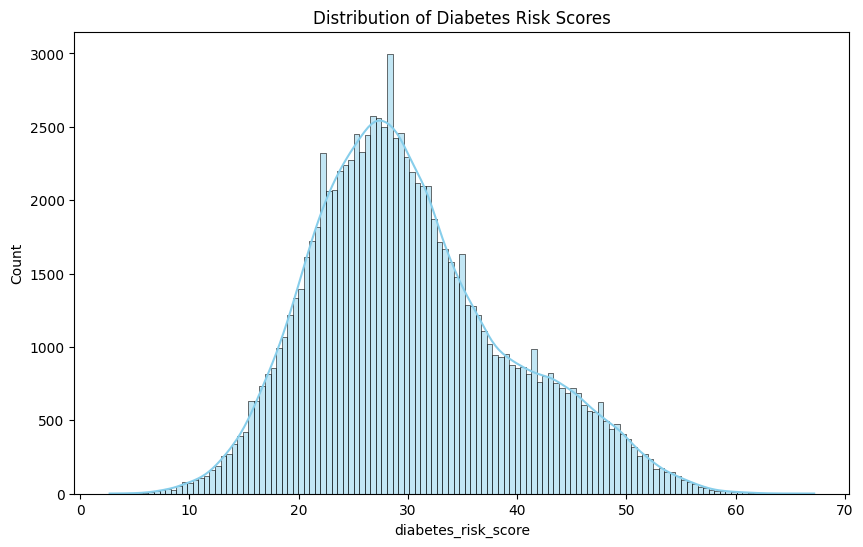

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the Regression Target
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['diabetes_risk_score'], kde=True, color='skyblue')
plt.title("Distribution of Diabetes Risk Scores")

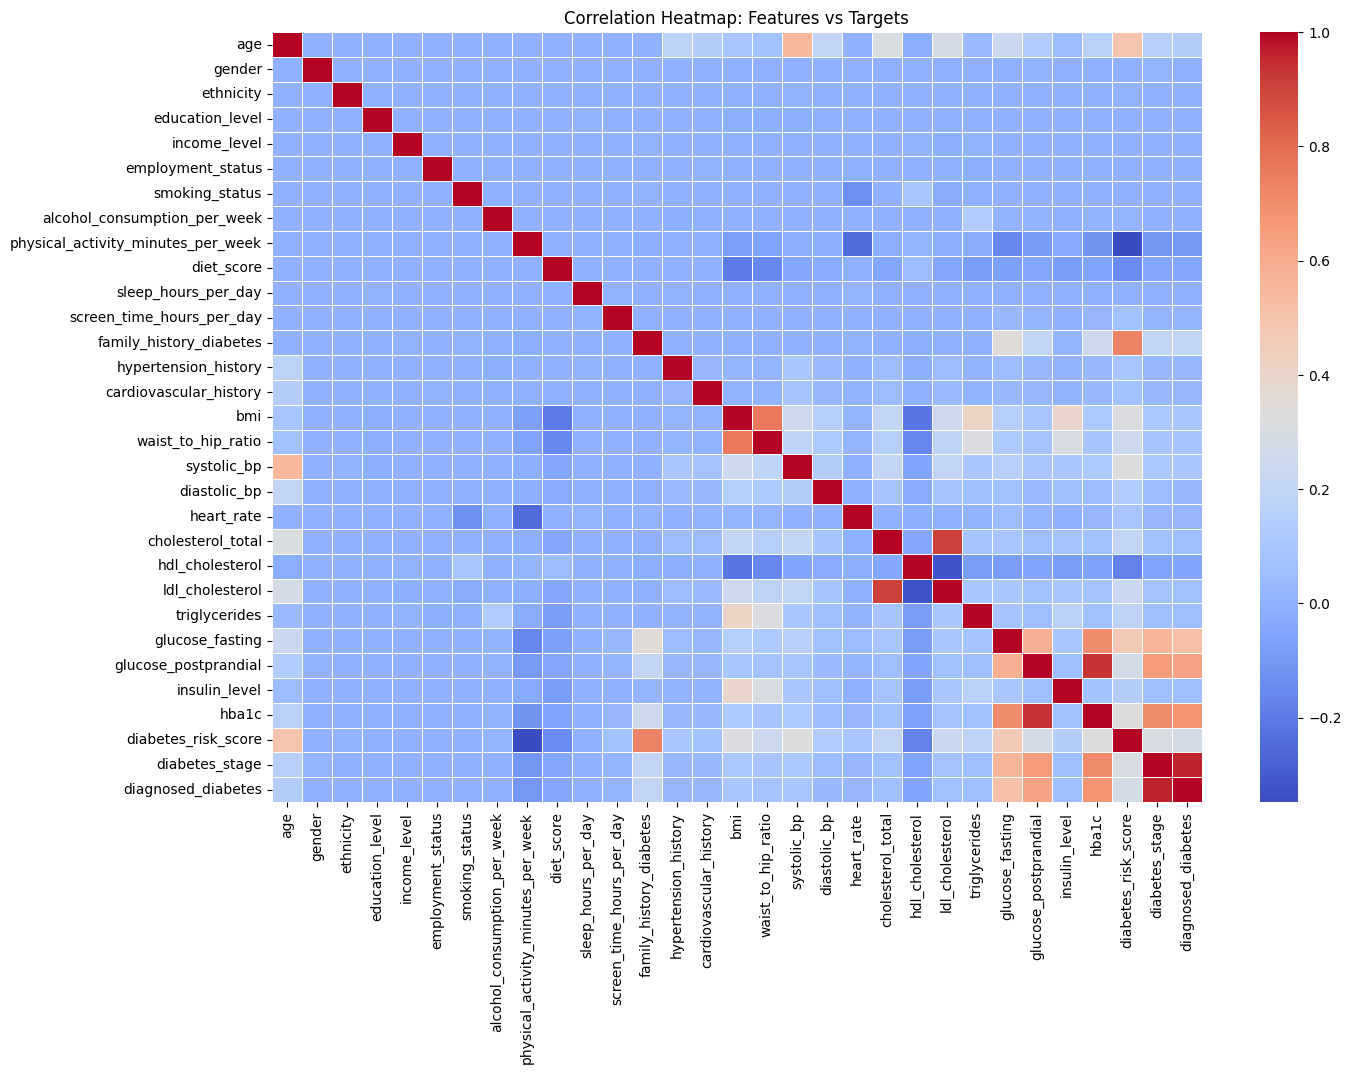

In [7]:
plt.figure(figsize=(15, 10))
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap: Features vs Targets") 
plt.show()

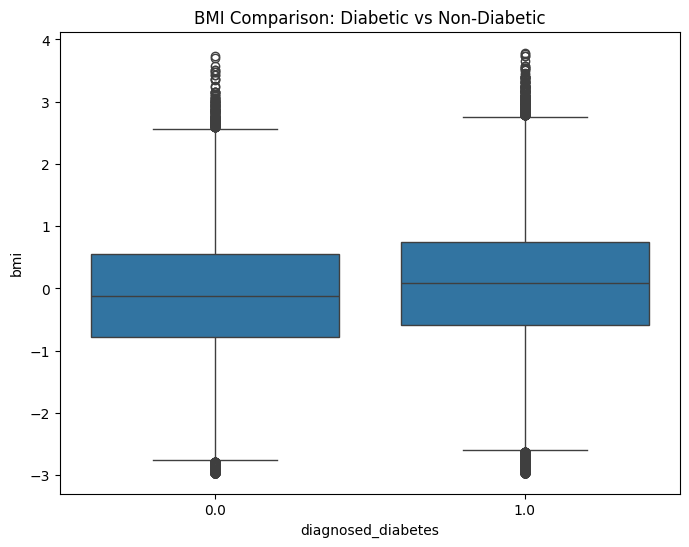

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosed_diabetes', y='bmi', data=df_cleaned)
plt.title("BMI Comparison: Diabetic vs Non-Diabetic") 
plt.show()

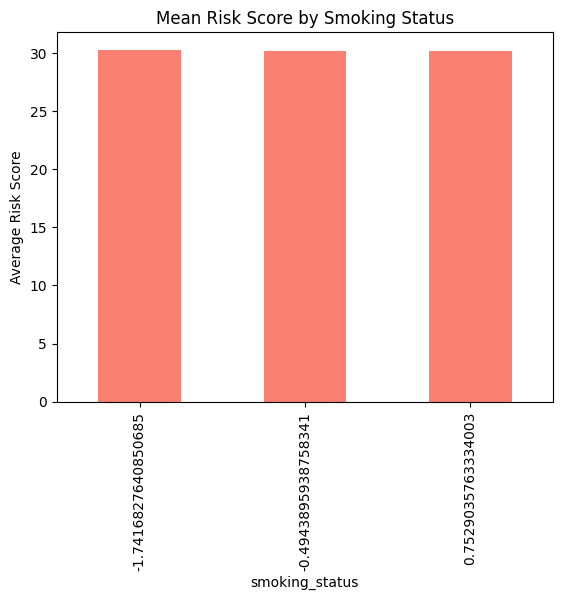

In [9]:
group_data = df_cleaned.groupby('smoking_status')['diabetes_risk_score'].mean()
group_data.plot(kind='bar', color='salmon')
plt.title("Mean Risk Score by Smoking Status") # 
plt.ylabel("Average Risk Score")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Define Features (X) and the Binary Target (y)
X = df_cleaned.drop(columns=['diagnosed_diabetes', 'diabetes_stage', 'diabetes_risk_score'])
y_binary = df_cleaned['diagnosed_diabetes']

# Stratified split for the Binary Classification task
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

print(f"Data Split Complete! Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Data Split Complete! Training rows: 80000, Testing rows: 20000



--- Logistic Regression Report ---
              precision    recall  f1-score   support

         0.0       0.84      0.81      0.82      8000
         1.0       0.87      0.90      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



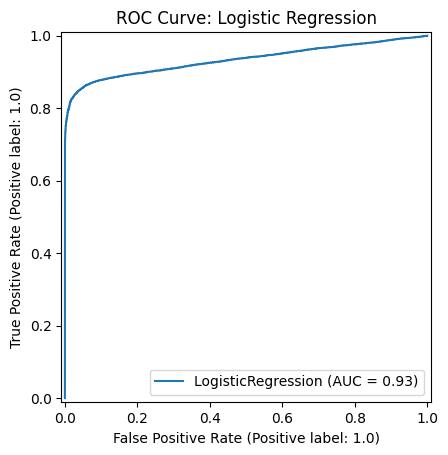


--- Decision Tree Report ---
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91      8000
         1.0       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



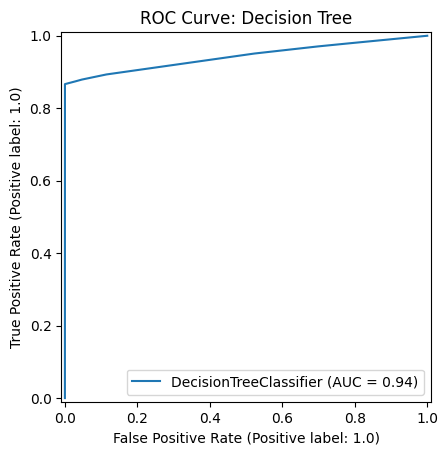


--- KNN Report ---
              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      8000
         1.0       0.84      0.83      0.84     12000

    accuracy                           0.81     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.81      0.81      0.81     20000



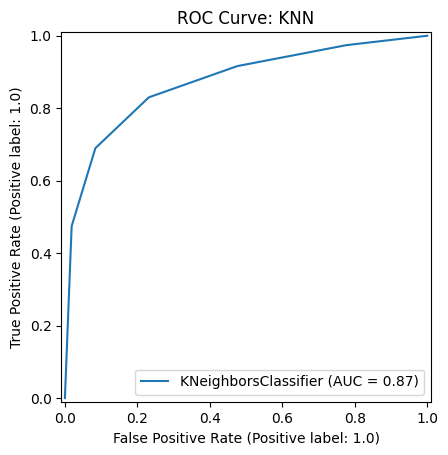

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Loop through models to train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n--- {name} Report ---")
    print(classification_report(y_test, y_pred))
    
    # Plot ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve: {name}")
    plt.show()

In [12]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

# Define the Multiclass Target
y_multi = df_cleaned['diabetes_stage']

# Split Data (Using stratify to keep stage proportions equal)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

# Train and Compare
multi_models = {
   
    "Logistic Regression": LogisticRegression(max_iter=1000), 
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "KNN": KNeighborsClassifier()
}

for name, model in multi_models.items():
    model.fit(X_train_m, y_train_m)
    y_pred_m = model.predict(X_test_m)
    
    # Calculate Metrics
    acc = accuracy_score(y_test_m, y_pred_m)
    f1 = f1_score(y_test_m, y_pred_m, average='macro')
    
    print(f"\n--- {name} (Multiclass) ---")
    print(f"Accuracy: {acc:.2%}")
    print(f"Macro-F1 Score: {f1:.4f}")
    
    # 4. Show Confusion Matrix
    cm = confusion_matrix(y_test_m, y_pred_m)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

NameError: name 'accuracy_score' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the Regression Target
y_reg = df_cleaned['diabetes_risk_score']

# Split Data (No stratification needed for continuous values)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Train and Compare
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42)
}

for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    y_pred_r = model.predict(X_test_r)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test_r, y_pred_r)
    mse = mean_squared_error(y_test_r, y_pred_r)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_r, y_pred_r)
    
    print(f"\n--- {name} (Regression) ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")


--- Linear Regression (Regression) ---
MAE: 0.4390
RMSE: 0.7446
R2 Score: 0.9933

--- Decision Tree Regressor (Regression) ---
MAE: 2.4278
RMSE: 3.0379
R2 Score: 0.8882


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Tuning Binary Classification (Logistic Regression example)
param_grid_bin = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_bin = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_bin, cv=5)
grid_bin.fit(X_train, y_train)
best_binary_model = grid_bin.best_estimator_

# 2. Tuning Multiclass (Decision Tree example)
param_grid_multi = {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]}
grid_multi = GridSearchCV(DecisionTreeClassifier(), param_grid_multi, cv=5)
grid_multi.fit(X_train_m, y_train_m)
best_multi_model = grid_multi.best_estimator_

In [ ]:
# 3. Tuning Regression (Decision Tree Regressor example)
param_grid_reg = {'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 2, 4]}
grid_reg = GridSearchCV(DecisionTreeRegressor(), param_grid_reg, cv=5)
grid_reg.fit(X_train_r, y_train_r)
best_reg_model = grid_reg.best_estimator_

print("Tuning Complete. Best parameters recorded.")

Tuning Complete. Best parameters recorded.


In [ ]:
import joblib
import os

# 1. Setup the correct path
model_dir = os.path.join('..', 'models')
os.makedirs(model_dir, exist_ok=True)

# 2. Export everything using your confirmed variable names
try:
    joblib.dump(best_binary_model, os.path.join(model_dir, 'binary_model.joblib'))
    joblib.dump(best_multi_model, os.path.join(model_dir, 'multiclass_model.joblib'))
    joblib.dump(best_reg_model, os.path.join(model_dir, 'regression_model.joblib'))
    
    # Use 'scaler_tool' as identified by your %who command
    joblib.dump(scaler_tool, os.path.join(model_dir, 'scaler.joblib'))
    
    print(f"✅ SUCCESS: All 4 files (including scaler.joblib) are now in {os.path.abspath(model_dir)}")
except NameError as e:
    print(f"❌ Still missing a variable: {e}")

✅ SUCCESS: All 4 files (including scaler.joblib) are now in c:\Users\Administrator\Desktop\diabetes_health_indicators_ml\models


In [13]:
print(list(scaler_tool.feature_names_in_))

['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']
